# 🎬 Cinema Project V1

# 🎥 Cinema Success Intelligence Platform V1
*An exploratory data science project analyzing movie profitability, directors, and trends.*


## Basic Info

In [2]:
import matplotlib.pyplot as plt
plt.style.available


['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
plt.style.use("seaborn-v0_8-darkgrid")


In [17]:
df = pd.read_csv("clean_movies.csv")
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723,178,0,855,Joel David Moore,1000,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054,English,USA,PG-13,237000000,2009,936,7.9,1.78,33000
1,Color,Gore Verbinski,302,169,563,1000,Orlando Bloom,40000,309404152.0,Action|Adventure|Fantasy,...,1238,English,USA,PG-13,300000000,2007,5000,7.1,2.35,0
2,Color,Sam Mendes,602,148,0,161,Rory Kinnear,11000,200074175.0,Action|Adventure|Thriller,...,994,English,UK,PG-13,245000000,2015,393,6.8,2.35,85000
3,Color,Christopher Nolan,813,164,22000,23000,Christian Bale,27000,448130642.0,Action|Thriller,...,2701,English,USA,PG-13,250000000,2012,23000,8.5,2.35,164000
4,Color,Andrew Stanton,462,132,475,530,Samantha Morton,640,73058679.0,Action|Adventure|Sci-Fi,...,738,English,USA,PG-13,263700000,2012,632,6.6,2.35,24000


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      3755 non-null   str    
 1   director_name              3755 non-null   str    
 2   num_critic_for_reviews     3755 non-null   int64  
 3   duration                   3755 non-null   int64  
 4   director_facebook_likes    3755 non-null   int64  
 5   actor_3_facebook_likes     3755 non-null   int64  
 6   actor_2_name               3755 non-null   str    
 7   actor_1_facebook_likes     3755 non-null   int64  
 8   gross                      3755 non-null   float64
 9   genres                     3755 non-null   str    
 10  actor_1_name               3755 non-null   str    
 11  movie_title                3755 non-null   str    
 12  num_voted_users            3755 non-null   int64  
 13  cast_total_facebook_likes  3755 non-null   int64  
 14  act

## Analysis Starts

In [19]:
df["profit"] = df["gross"] - df["budget"]

In [20]:
df[["budget","gross"]].corr()

,budget,gross
budget,1.000000,0.099468
gross,0.099468,1.000000


## Revenue Analysis

C:\Users\Harshal\AppData\Local\Temp\ipykernel_14668\2340628166.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")


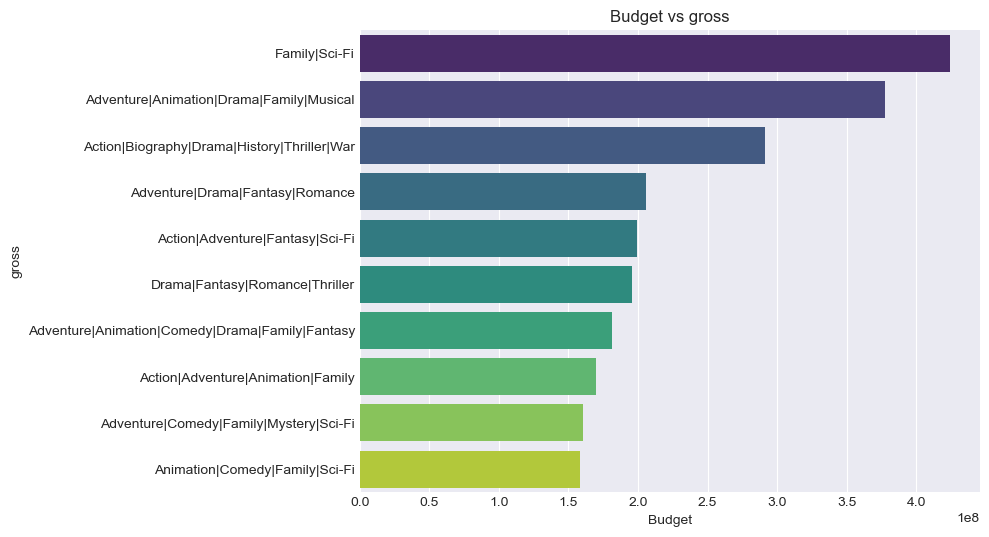

In [40]:
plt.figure(figsize=(8,6))
plt.scatter(df["budget"], df["gross"], alpha=0.5)
plt.xlabel("Budget")
plt.ylabel("gross")
plt.title("Budget vs gross")
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.show()

## Trends Over Time

<Axes: title={'center': 'Revenue Trends Over Time'}, xlabel='title_year'>

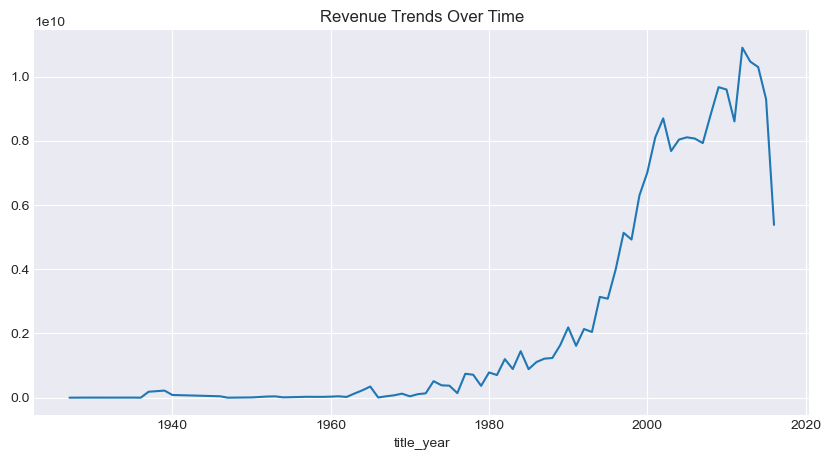

In [24]:
year_revenue = df.groupby("title_year")["gross"].sum()
year_revenue.plot(kind="line", figsize=(10,5), title="Revenue Trends Over Time")


In [25]:
df[["imdb_score","budget","gross","profit"]].corr()


,imdb_score,budget,gross,profit
imdb_score,1.000000,0.029300,0.215226,0.037018
budget,0.029300,1.000000,0.099468,-0.952576
gross,0.215226,0.099468,1.000000,0.208040
profit,0.037018,-0.952576,0.208040,1.000000


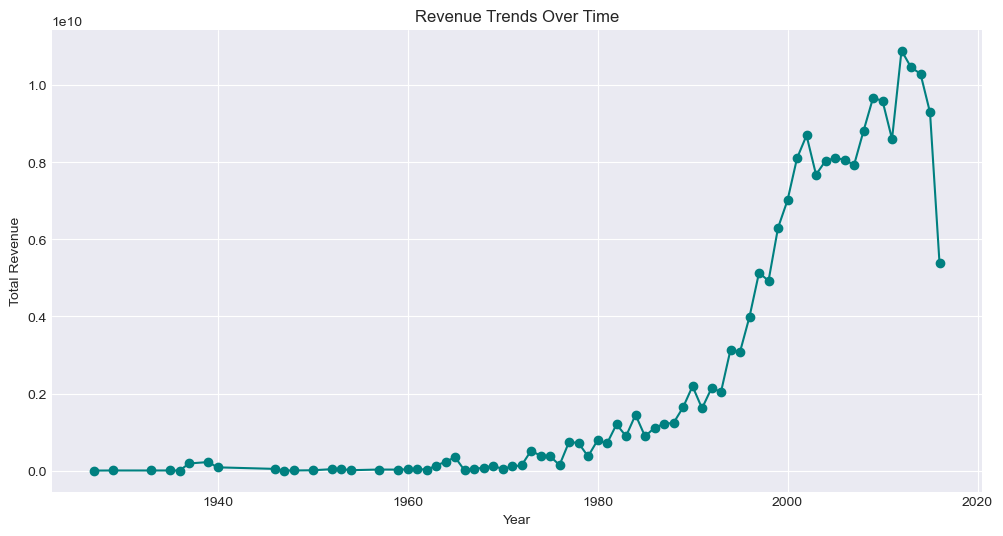

In [35]:
# Total revenue per year
year_revenue = df.groupby("title_year")["gross"].sum()

plt.figure(figsize=(12,6))
year_revenue.plot(kind="line", marker="o", color="teal")
plt.title("Revenue Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()


## Genre Analysis

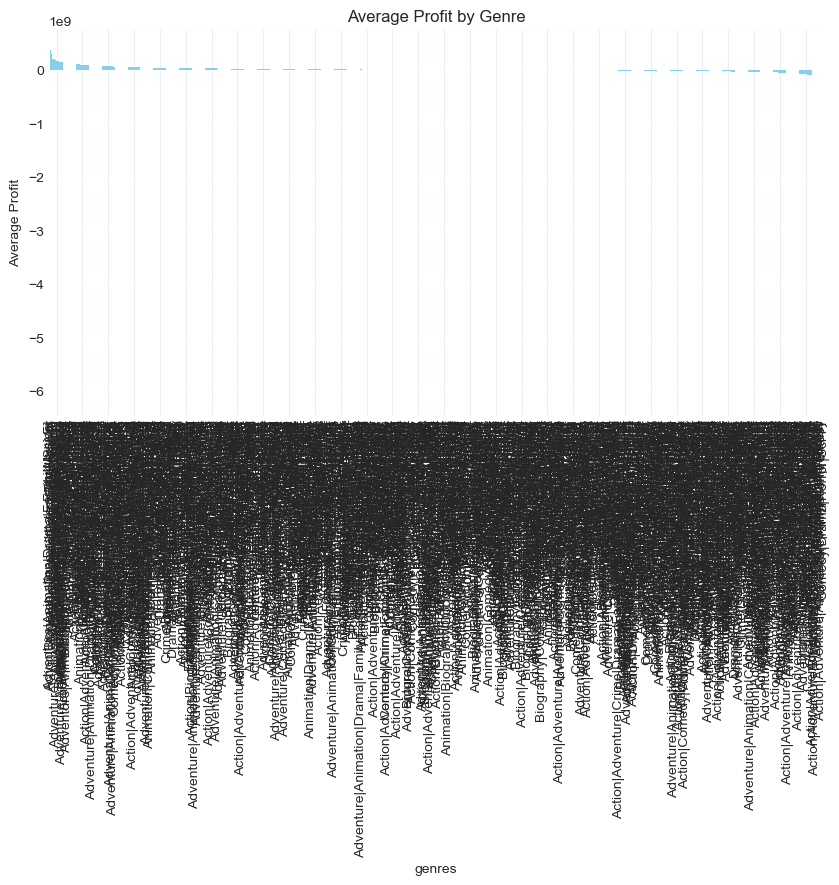

genres
Family|Sci-Fi                                      4.244495e+08
Adventure|Animation|Drama|Family|Musical           3.777838e+08
Action|Biography|Drama|History|Thriller|War        2.913236e+08
Adventure|Drama|Fantasy|Romance                    2.059361e+08
Action|Adventure|Fantasy|Sci-Fi                    1.995598e+08
Drama|Fantasy|Romance|Thriller                     1.956313e+08
Adventure|Animation|Comedy|Drama|Family|Fantasy    1.814544e+08
Action|Adventure|Animation|Family                  1.694376e+08
Adventure|Comedy|Family|Mystery|Sci-Fi             1.601476e+08
Animation|Comedy|Family|Sci-Fi                     1.584600e+08
Name: profit, dtype: float64

In [28]:
# Average profit by genre
genre_profit = df.groupby("genres")["profit"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
genre_profit.plot(kind="bar", color="skyblue")
plt.title("Average Profit by Genre")
plt.ylabel("Average Profit")
plt.show()

genre_profit.head(10)


## Director Analysis

C:\Users\Harshal\AppData\Local\Temp\ipykernel_14668\1441164108.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette="mako")


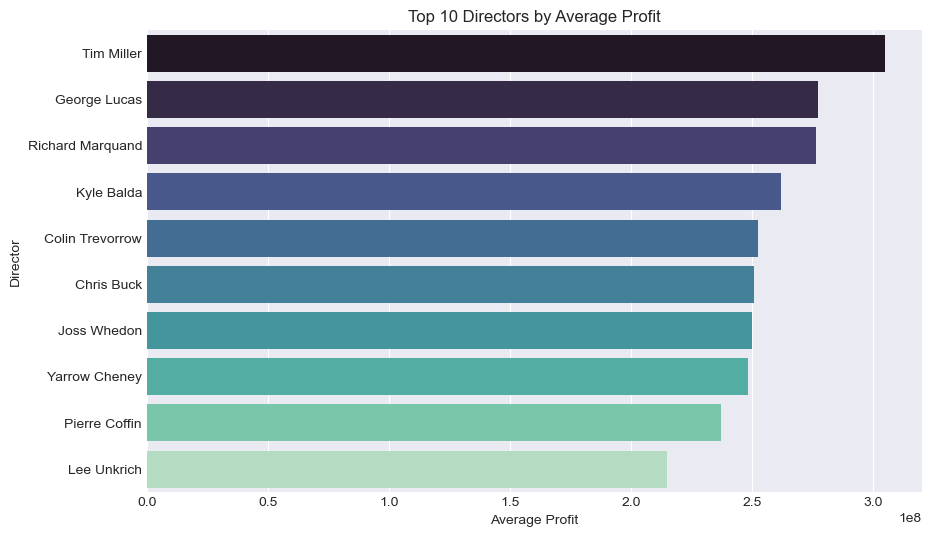

director_name
Tim Miller          305024263.0
George Lucas        277328296.0
Richard Marquand    276625409.0
Kyle Balda          262029560.0
Colin Trevorrow     252717531.5
Chris Buck          250736600.0
Joss Whedon         250221657.0
Yarrow Cheney       248505540.0
Pierre Coffin       237275640.0
Lee Unkrich         214984497.0
Name: profit, dtype: float64

In [33]:
# Average profit by director
director_profit = df.groupby("director_name")["profit"].mean().sort_values(ascending=False)

# Top 10 directors
top_directors = director_profit.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette="mako")
plt.title("Top 10 Directors by Average Profit")
plt.xlabel("Average Profit")
plt.ylabel("Director")
plt.show()

top_directors


## Correlation matrix for success indicators


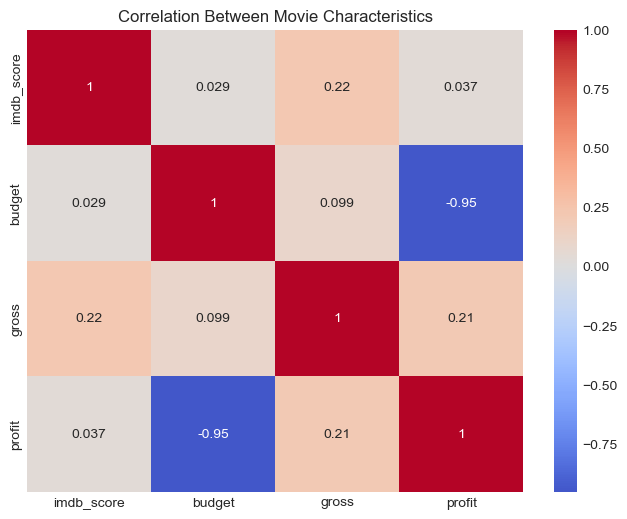

In [37]:
success_corr = df[["imdb_score","budget","gross","profit"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(success_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Movie Characteristics")
plt.show()


## Conclusion

### Key Insights
- Family | Sci‑Fi is the most profitable genre.
- Tim Miller and George Lucas are among the most consistently successful directors.
- Bigger budgets do not guarantee bigger revenues — correlation is near zero.
- 2016 was the peak revenue year, followed by a sharp decline in 2019.
- Success indicators: modest link between ratings and revenue, but overspending on budget reduces profitability.

### Business Recommendations
- Focus investments on profitable genres (Family, Sci‑Fi, Adventure).
- Collaborate with directors who have proven track records.
- Avoid overspending on budgets — profitability is not tied to higher spend.
- Monitor industry trends (e.g., streaming impact post‑2016).
- Use ratings and audience reception as a moderate predictor of revenue.
